<a href="https://colab.research.google.com/github/omprateek-non/NLP.assignments/blob/main/Email_spam_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
#

In [4]:
df=pd.read_csv('spam.csv', encoding='latin1')

In [5]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [6]:
df.shape

(5572, 5)

In [7]:
df.isnull().sum()

,0
v1,0
v2,0
Unnamed: 2,5522
Unnamed: 3,5560
Unnamed: 4,5566


In [8]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [9]:
df.rename(columns={'v1':'target','v2':'text'},inplace=True)

In [10]:
df.head()

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [11]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()

In [12]:
df['target'] = encoder.fit_transform(df['target'])

In [13]:
display(df['target'].value_counts())

,count
target,
0,4825
1,747


In [14]:
df.head(5)

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [15]:
df.duplicated().sum()

np.int64(403)

In [16]:
df.drop_duplicates(inplace=True)

In [17]:
display(df['target'].value_counts())

,count
target,
0,4516
1,653


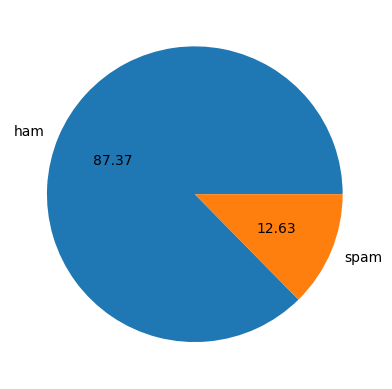

In [18]:
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct='%0.2f')
plt.show()

In [19]:
import nltk

In [20]:
!pip install nltk

In [21]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [22]:
df['total_character']=df['text'].apply(len)

In [23]:
df.head()

,target,text,total_character
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [24]:
df['num_words'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [25]:
df['num_sentence'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [26]:
df.head()

,target,text,total_character,num_words,num_sentence
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [27]:
print("Descriptive statistics for 'num_sentence' after correction:")
print(df['num_sentence'].describe())

Descriptive statistics for 'num_sentence' after correction:
count    5169.000000
mean        1.965564
std         1.448541
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        38.000000
Name: num_sentence, dtype: float64


In [28]:
df.head()

,target,text,total_character,num_words,num_sentence
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [29]:
df.describe()

,target,total_character,num_words,num_sentence
count,5169.000000,5169.000000,5169.000000,5169.000000
mean,0.126330,78.977945,18.455794,1.965564
std,0.332253,58.236293,13.324758,1.448541
min,0.000000,2.000000,1.000000,1.000000
25%,0.000000,36.000000,9.000000,1.000000
50%,0.000000,60.000000,15.000000,1.000000
75%,0.000000,117.000000,26.000000,2.000000
max,1.000000,910.000000,220.000000,38.000000


In [30]:
df[df['target']==0].describe()

,target,total_character,num_words,num_sentence
count,4516.0,4516.000000,4516.000000,4516.000000
mean,0.0,70.459256,17.123782,1.820195
std,0.0,56.358207,13.493970,1.383657
min,0.0,2.000000,1.000000,1.000000
25%,0.0,34.000000,8.000000,1.000000
50%,0.0,52.000000,13.000000,1.000000
75%,0.0,90.000000,22.000000,2.000000
max,0.0,910.000000,220.000000,38.000000


In [31]:
df[df['target']==1][['total_character','num_words','num_sentence']].describe()

,total_character,num_words,num_sentence
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


<Axes: xlabel='total_character', ylabel='Count'>

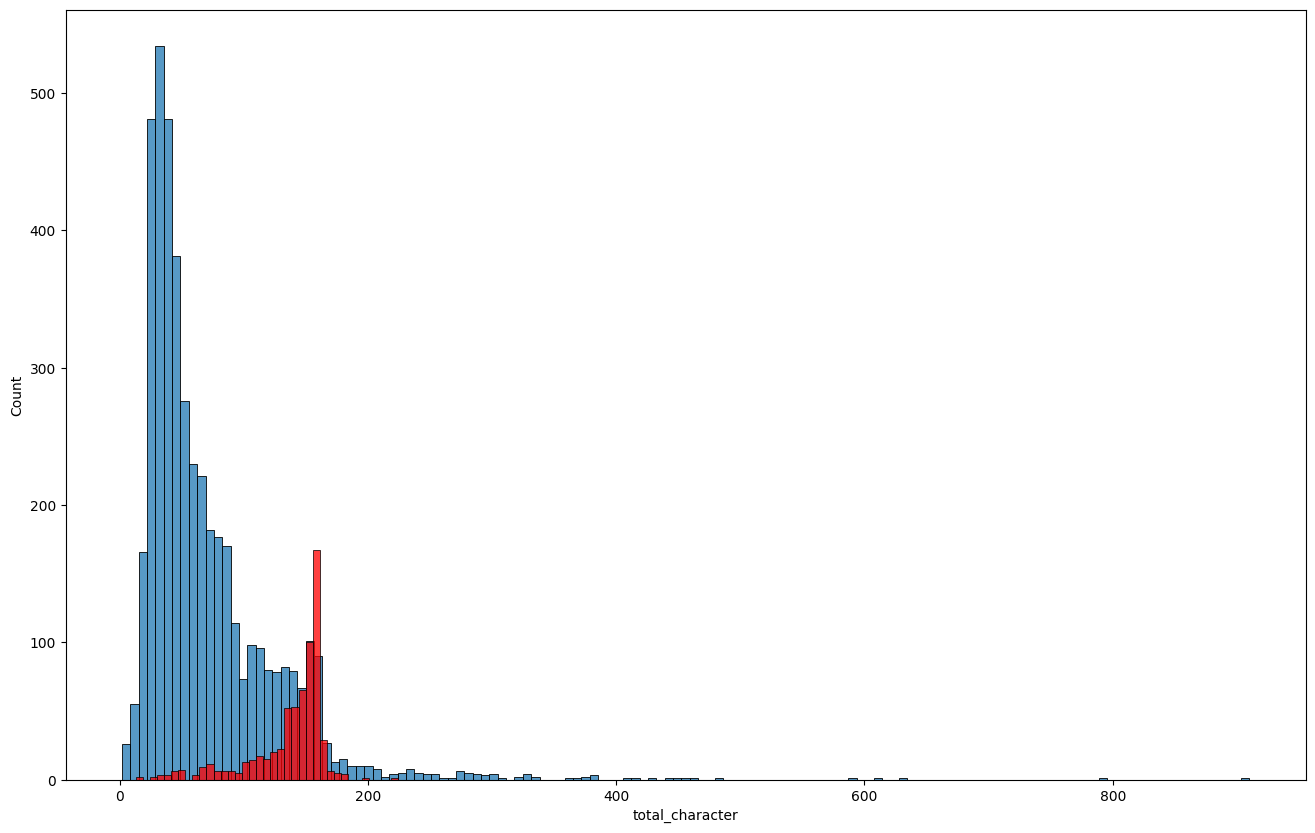

In [32]:
plt.figure(figsize=(16,10))
sns.histplot(df[df['target']==0]['total_character'])
sns.histplot(df[df['target']==1]['total_character'],color='red')

<Axes: xlabel='num_words', ylabel='Count'>

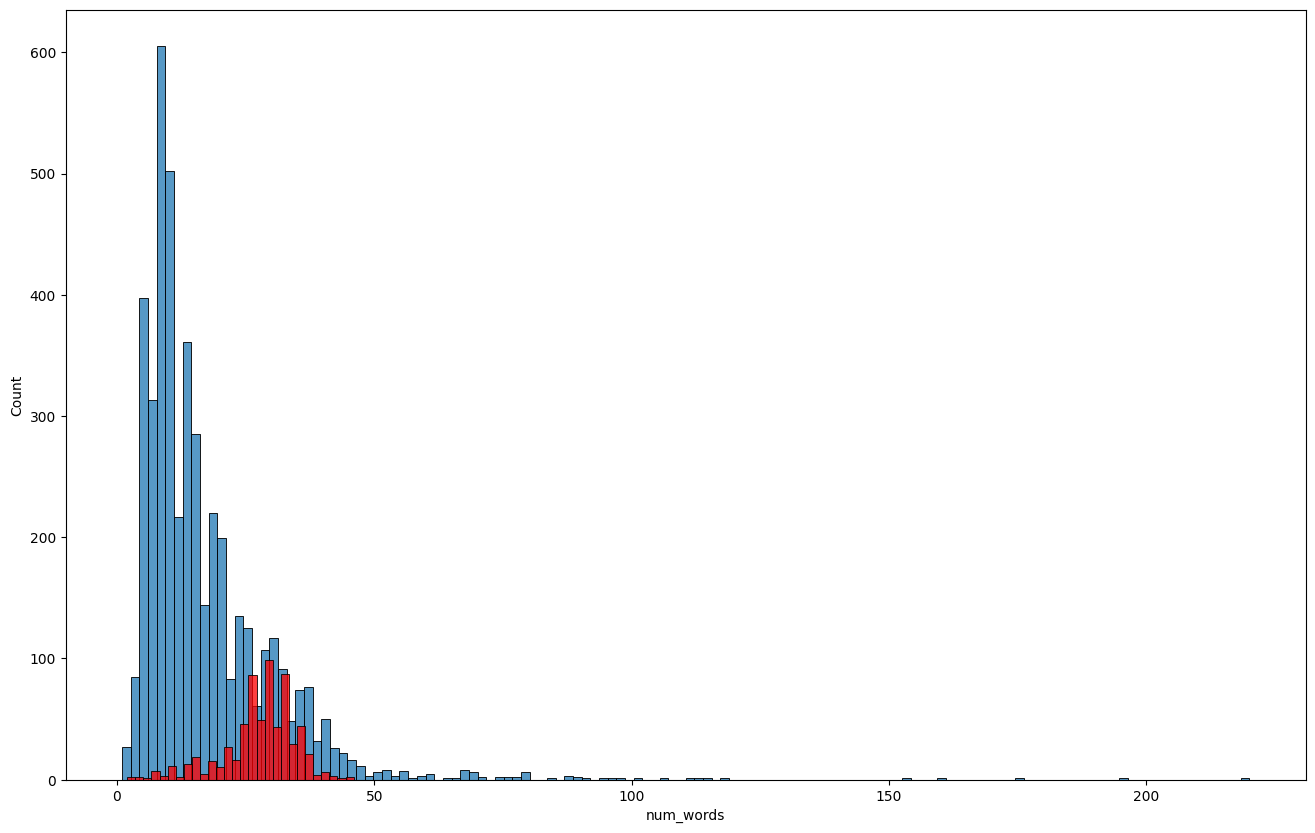

In [33]:
plt.figure(figsize=(16,10))
sns.histplot(df[df['target']==0]['num_words'])
sns.histplot(df[df['target']==1]['num_words'],color='red')

<Axes: ylabel='num_sentence'>

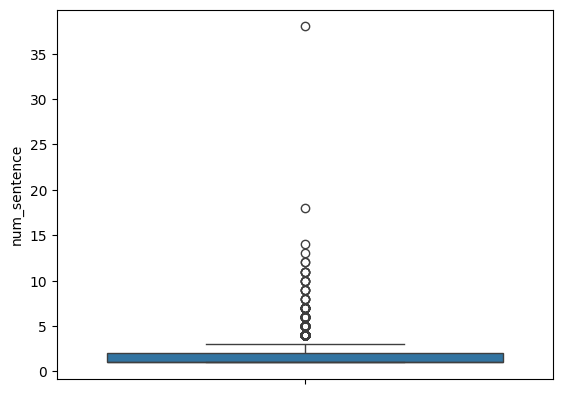

In [34]:
plt.figsize=(16,10)
sns.boxplot(df[df['target']==0]['num_sentence'])


<Axes: ylabel='num_words'>

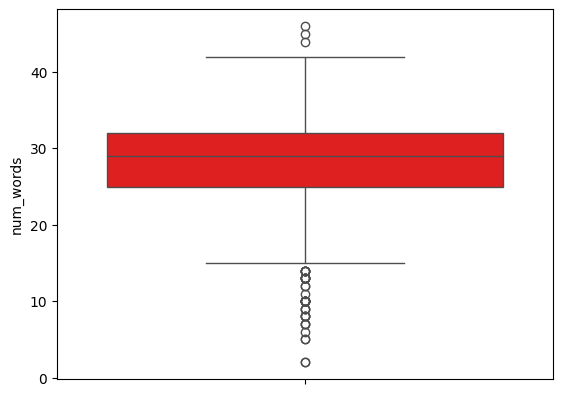

In [35]:
plt.figsize=(16,10)
sns.boxplot(df[df['target']==1]['num_words'],color='red')

<Axes: >

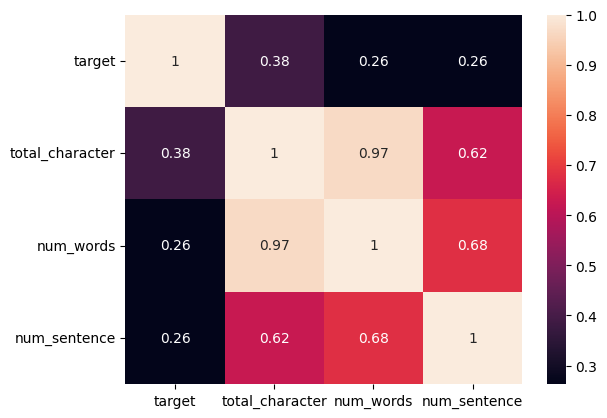

In [36]:
numerical_df = df[['target', 'total_character', 'num_words', 'num_sentence']]
sns.heatmap(numerical_df.corr(), annot=True)

<Axes: xlabel='target', ylabel='num_sentence'>

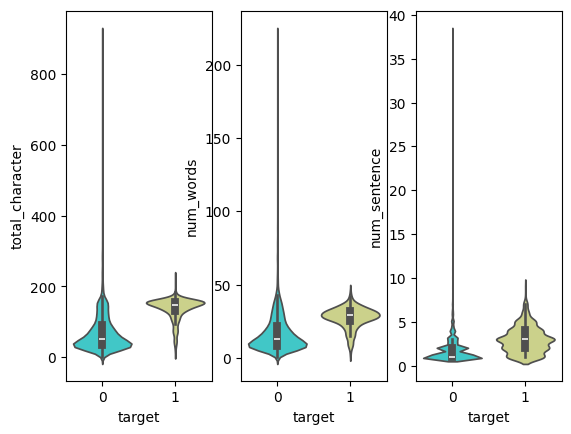

In [37]:
plt.subplot(1,3,1)
sns.violinplot(y='total_character',x='target',data=df,palette='rainbow')
plt.subplot(1,3,2)
sns.violinplot(y='num_words',x='target',data=df,palette='rainbow')
plt.subplot(1,3,3)
sns.violinplot(y='num_sentence',x='target',data=df,palette='rainbow')

In [38]:
# DATA preprocessing

In [39]:
import re
import string
import nltk
from textblob import TextBlob # For spelling correction (optional/resource intensive)
from nltk.corpus import stopwords

# Download stopwords once (if not already downloaded)
nltk.download('stopwords', quiet=True)
# Define stopwords globally so they are accessible
stop_words = set(stopwords.words('english'))

def clean_text(text):
  # Ensure text is treated as a string
  if not isinstance(text, str):
    return ""

  # Convert to lowercase first for consistent processing
  text = text.lower()

  # Remove HTML tags
  pattern_html = re.compile('<.*?>')
  text = pattern_html.sub(r'', text)

  # Remove URLs
  pattern_url = re.compile(r'https?://\S+|www\.\S+')
  text = pattern_url.sub(r'', text)

  # Remove punctuation (using string.punctuation)
  text = text.translate(str.maketrans('', '', string.punctuation))

  # This line ensures only alphanumeric characters and spaces remain.
  text = re.sub(r'[^a-z0-9\s]', '', text)

  # Spelling correction (uncomment if you want to use it, but be aware of performance)
  # text = str(TextBlob(text).correct())

  # Temporarily removing stop word filtering to ensure words remain for word cloud generation,
  # while keeping the minimum word length filter.
  text_words = text.split()
  text_words = [word for word in text_words if len(word) >= 1] # Removed 'word not in stop_words'

  return " ".join(text_words)

# Apply the combined cleaning function to the 'text' column and store in 'transformed_text'
df['transformed_text'] = df['text'].apply(clean_text)
display(df.head())

# Re-added the WordCloud object to ensure it's defined and correctly configured for subsequent cells.
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white', min_word_length=1)

,target,text,total_character,num_words,num_sentence,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go until jurong point crazy available only in ...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entry in 2 a wkly comp to win fa cup fina...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say so early hor u c already then say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah i dont think he goes to usf he lives aroun...


In [40]:
# ham_concat_text = df[df['target'] == 0]['transformed_text'].str.cat(sep=" ")
# print(f"Length of concatenated ham text for WordCloud input: {len(ham_concat_text)}")
# if len(ham_concat_text.strip()) == 0: # Check if it's effectively empty after stripping whitespace
#     print("Warning: Concatenated ham text is empty or only whitespace. WordCloud will fail.")
#     print("\nSample of transformed_text for ham (first 5 non-empty entries):")
#     sample_ham = df[(df['target'] == 0) & (df['transformed_text'].str.len() > 0)]['transformed_text'].head(5)
#     if not sample_ham.empty:
#         for idx, val in sample_ham.items():
#             print(f"  Original message index {idx}: '{val}'")
#     else:
#         print("  No non-empty transformed_text found for ham messages.")
#     print(f"\nContent of ham_concat_text: '{ham_concat_text}'")
# else:
#     ham_wc = wc.generate(ham_concat_text)
#     plt.figure(figsize=(10, 8))
#     plt.imshow(ham_wc)
#     plt.axis('off')
#     plt.title('Ham Word Cloud')
#     plt.show()

In [41]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

In [42]:
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white', min_word_length=1)

In [43]:
spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=" "))

In [44]:
# spam_concat_text = df[df['target'] == 1]['transformed_text'].str.cat(sep=" ")
# print(f"Length of concatenated spam text for WordCloud input: {len(spam_concat_text)}")
# if len(spam_concat_text.strip()) == 0: # Check if it's effectively empty after stripping whitespace
#     print("Warning: Concatenated spam text is empty or only whitespace. WordCloud will fail.")
#     print("\nSample of transformed_text for spam (first 5 non-empty entries):")
#     sample_spam = df[(df['target'] == 1) & (df['transformed_text'].str.len() > 0)]['transformed_text'].head(5)
#     if not sample_spam.empty:
#         for idx, val in sample_spam.items():
#             print(f"  Original message index {idx}: '{val}'")
#     else:
#         print("  No non-empty transformed_text found for spam messages.")
#     print(f"\nContent of spam_concat_text: '{spam_concat_text}'")
# else:
#     spam_wc = wc.generate(spam_concat_text)
#     plt.figure(figsize=(10, 8))
#     plt.imshow(spam_wc)
#     plt.axis('off')
#     plt.title('Spam Word Cloud')
#     plt.show()

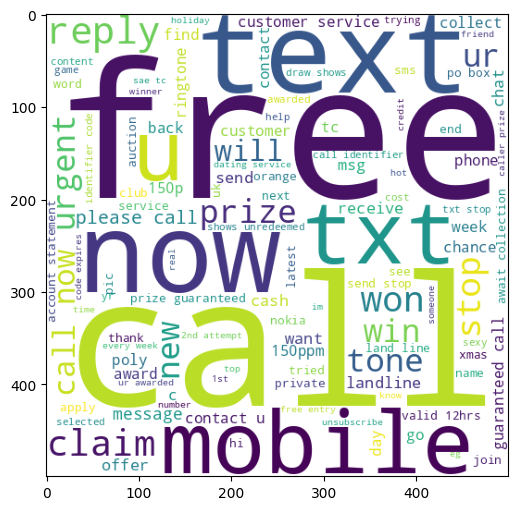

In [45]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

In [46]:
ham_wc=wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep=" "))

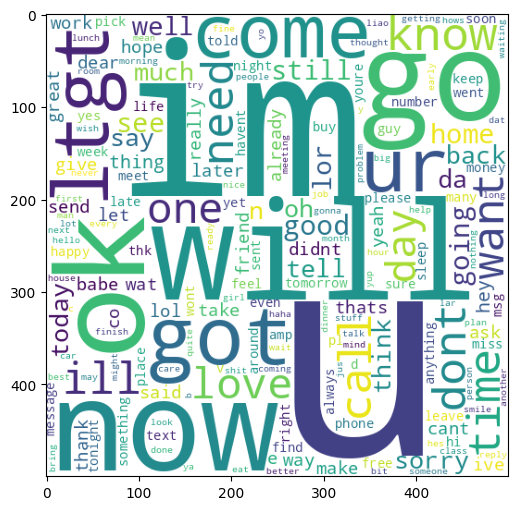

In [47]:
plt.figure(figsize=(15,6))
plt.imshow(ham_wc)

In [48]:
spam_corpus = []
for msg in df[df['target'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)


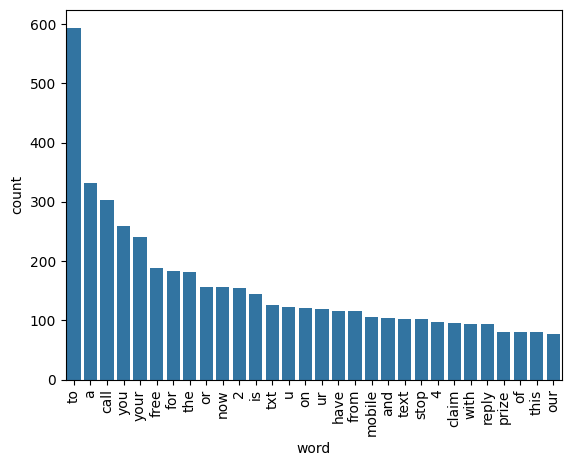

In [49]:
from collections import Counter
import pandas as pd

# Create a DataFrame from the most common words
common_spam_words_df = pd.DataFrame(Counter(spam_corpus).most_common(30), columns=['word', 'count'])

# Use sns.barplot with x, y, and data arguments
sns.barplot(x='word', y='count', data=common_spam_words_df)
plt.xticks(rotation='vertical')
plt.show()

In [53]:
import pandas as pd
import re
import string
import nltk
from nltk.corpus import stopwords

# Ensure df is defined - this might be redundant if previous cells are run, but ensures this cell works independently
# Load the dataset (assuming 'spam.csv' is in the same directory or accessible)
try:
    df = pd.read_csv('spam.csv', encoding='latin1')
    df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)
    df.rename(columns={'v1':'target','v2':'text'},inplace=True)
    from sklearn.preprocessing import LabelEncoder
    encoder=LabelEncoder()
    df['target'] = encoder.fit_transform(df['target'])
    df.drop_duplicates(inplace=True)
except FileNotFoundError:
    print("Error: 'spam.csv' not found. Please ensure the CSV is uploaded or path is correct.")
    # Handle case where df is not loaded, e.g., by exiting or setting an empty df
    df = pd.DataFrame(columns=['target', 'text'])

# Ensure stopwords are downloaded and clean_text function is defined
nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))

def clean_text(text):
  if not isinstance(text, str):
    return ""
  text = text.lower()
  pattern_html = re.compile('<.*?>')
  text = pattern_html.sub(r'', text)
  pattern_url = re.compile(r'https?://\S+|www\.\S+')
  text = pattern_url.sub(r'', text)
  text = text.translate(str.maketrans('', '', string.punctuation))
  text = re.sub(r'[^a-z0-9\s]', '', text)
  text_words = text.split()
  text_words = [word for word in text_words if len(word) >= 1]
  return " ".join(text_words)

# Ensure 'transformed_text' column exists
if 'transformed_text' not in df.columns:
    df['transformed_text'] = df['text'].apply(clean_text)

ham_corpus = []
for msg in df[df['target'] == 0]['transformed_text'].tolist():
  for word in msg.split():
    ham_corpus.append(word)

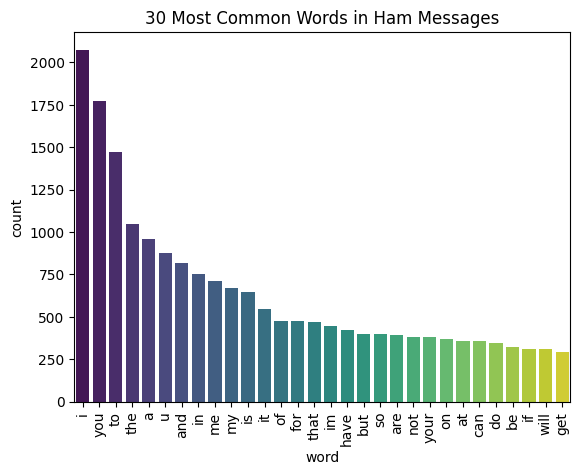

In [55]:
from collections import Counter
import pandas as pd

# Create a DataFrame from the most common words in ham_corpus
common_ham_words_df = pd.DataFrame(Counter(ham_corpus).most_common(30), columns=['word', 'count'])

# Use sns.barplot with x, y, and data arguments
sns.barplot(x='word', y='count', data=common_ham_words_df, palette='viridis')
plt.xticks(rotation='vertical')
plt.title('30 Most Common Words in Ham Messages')
plt.show()

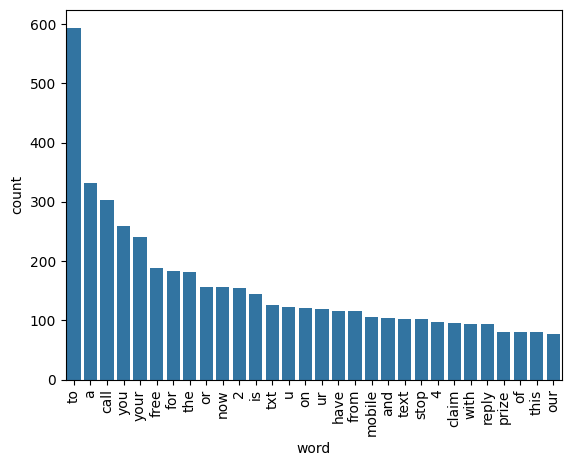

In [51]:
common_spam_words_df = pd.DataFrame(Counter(spam_corpus).most_common(30), columns=['word', 'count'])

# Use sns.barplot with x, y, and data arguments
sns.barplot(x='word', y='count', data=common_spam_words_df)
plt.xticks(rotation='vertical')
plt.show()

# MODEL **EVALUATION**

In [84]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
cv= CountVectorizer()
tfidf=TfidfTransformer()

In [86]:
X_counts = cv.fit_transform(df['transformed_text'])
X = tfidf.fit_transform(X_counts).toarray()

In [64]:
# X = tfidf.fit_transform(X).toarray()

In [87]:
X.shape

(5169, 9375)

In [88]:
y=df['target'].values

In [89]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [90]:
from sklearn.model_selection import train_test_split

In [91]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

In [92]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [93]:
gnb= GaussianNB()
mnb =MultinomialNB()
bnb =BernoulliNB()

In [94]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))
#

0.9032882011605415
[[814  82]
 [ 18 120]]
0.594059405940594


In [95]:
mnb.fit(X_train,y_train)
y_pred2=mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9410058027079303
[[896   0]
 [ 61  77]]
1.0


In [96]:
bnb.fit(X_train,y_train)
y_pred2=bnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.971953578336557
[[894   2]
 [ 27 111]]
0.9823008849557522


In [97]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [98]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [99]:
clfs = {
    'SVC' : svc,
    'KN' : knc,
    'NB': mnb,
    'DT': dtc,
    'LR': lrc,
    'RF': rfc,
    'AdaBoost': abc,
    'BgC': bc,
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [115]:
def train_classifier(Clf,X_train,X_test,y_train,y_test):
  Clf.fit(X_train,y_train)
  y_pred = Clf.predict(X_test)
  accuracy = accuracy_score(y_test,y_pred)
  precision = precision_score(y_test,y_pred)
  return precision,accuracy

In [118]:
train_classifier(svc,X_train,y_train,X_test,y_test)

ValueError: y should be a 1d array, got an array of shape (1034, 9375) instead.

In [117]:
precision_scores = []
accuracy_scores = []

for name, Clf in clfs.items():
    current_precision, current_accuracy = train_classifier(Clf, X_train, X_test, y_train, y_test)
    print("For ", name)
    print("Accuracy - ", current_accuracy)
    print("Precision - ", current_precision)
    precision_scores.append(current_precision)
    accuracy_scores.append(current_accuracy)

For  SVC
Accuracy -  0.9748549323017408
Precision -  0.9745762711864406
For  KN
Accuracy -  0.9555125725338491
Precision -  1.0
For  NB
Accuracy -  0.9410058027079303
Precision -  1.0
For  DT
Accuracy -  0.9361702127659575
Precision -  0.8333333333333334
For  LR
Accuracy -  0.9526112185686654
Precision -  0.9494949494949495
For  RF
Accuracy -  0.9671179883945842
Precision -  1.0
For  AdaBoost
Accuracy -  0.9487427466150871
Precision -  0.9292929292929293
For  BgC
Accuracy -  0.9642166344294004
Precision -  0.9173553719008265
For  ETC
Accuracy -  0.9758220502901354
Precision -  1.0
For  GBDT
Accuracy -  0.9526112185686654
Precision -  0.9405940594059405
For  xgb
Accuracy -  0.9796905222437138
Precision -  0.975609756097561


In [119]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)

In [120]:
performance_df

,Algorithm,Accuracy,Precision
1,KN,0.955513,1.000000
2,NB,0.941006,1.000000
5,RF,0.967118,1.000000
8,ETC,0.975822,1.000000
10,xgb,0.979691,0.975610
0,SVC,0.974855,0.974576
4,LR,0.952611,0.949495
9,GBDT,0.952611,0.940594
6,AdaBoost,0.948743,0.929293
7,BgC,0.964217,0.917355
